# 03 - Patrones temporales

## 1. Dependencias

In [1]:
#Instalar dependencias
%pip install pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2. Configuración

In [2]:
#Librerías
import platform
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import FuncFormatter

In [3]:
#Configuración
SEMILLA = 20260727
UMBRAL_REGULARIDAD = 0.75
MIN_FECHAS_REGULARIDAD = 3
MIN_SEMANAS_TENDENCIA = 8
MIN_TRANSACCIONES_TENDENCIA = 5
UMBRAL_CAMBIO_PCT = 25.0
MIN_ANTECEDENTES_EVENTO = 5
UMBRAL_EVENTO_INUSUAL = 3.5

ruta_transacciones = Path('../Datasets/transacciones_contextualizadas.csv')
ruta_resultados = Path('../Resultados')
ruta_graficas = ruta_resultados / 'Graficas'

versiones = pd.DataFrame([
    {'componente': 'python', 'version': sys.version.split()[0]},
    {'componente': 'pandas', 'version': pd.__version__},
    {'componente': 'numpy', 'version': np.__version__},
    {'componente': 'matplotlib', 'version': plt.matplotlib.__version__},
    {'componente': 'sistema', 'version': platform.platform()},
])

display(versiones)

,componente,version
0,python,3.14.3
1,pandas,3.0.3
2,numpy,2.5.1
3,matplotlib,3.11.1
4,sistema,macOS-26.5.2-arm64-arm-64bit-Mach-O


## 3. Carga y contrato temporal

In [4]:
#Cargar transacciones
transacciones = pd.read_csv(ruta_transacciones, low_memory=False)
transacciones['fecha'] = pd.to_datetime(transacciones['fecha'], errors='coerce')
transacciones['valor'] = pd.to_numeric(transacciones['valor'], errors='coerce')
transacciones = transacciones.sort_values(['perfil_id', 'fecha', 'transaccion_id']).reset_index(drop=True)
display(transacciones.head(5))

,transaccion_id,perfil_id,version_perfil_aplicada,fecha,descripcion_original,descripcion_normalizada,valor,moneda,direccion,tipo_movimiento,...,evidencia_contextual,confianza_objetivo,etiqueta_revisada,canal,particion,historia_financiera_controlada,es_sintetico,version_taxonomia,version_esquema,huella_registro
0,TX_0001_0001,PERF_0001,1,2026-04-02,PAGO ARRIENDO,pago arriendo,427000,COP,salida,gasto,...,descripcion:pago arriendo,0.889,si,bancario,train,acumulacion_estable,si,roadmap_10.1_mvp_cerrado_v1.1,fincoah_mvp_co_v1.1,88094df9256d8c73dfaaaa0064ff648cacb74b09ef7a10...
1,TX_0001_0002,PERF_0001,1,2026-04-02,ALMUERZO,almuerzo,54000,COP,salida,gasto,...,descripcion:almuerzo,0.959,si,bancario,train,acumulacion_estable,si,roadmap_10.1_mvp_cerrado_v1.1,fincoah_mvp_co_v1.1,e8330155be5651fc75e38d1ae17581f9df3fcda8fe049b...
2,TX_0001_0003,PERF_0001,1,2026-04-03,REPUESTO TRANSPORTE,repuesto transporte,70000,COP,salida,gasto,...,descripcion:repuesto transporte,0.883,si,bancario,train,acumulacion_estable,si,roadmap_10.1_mvp_cerrado_v1.1,fincoah_mvp_co_v1.1,75f71d21196faceaa5104eac2b33e34c4d27cfbe9fb080...
3,TX_0001_0004,PERF_0001,1,2026-04-03,HOTEL TURISMO,hotel turismo,90000,COP,salida,gasto,...,hobby:turismo_y_viajes | descripcion:hotel tur...,0.956,si,bancario,train,acumulacion_estable,si,roadmap_10.1_mvp_cerrado_v1.1,fincoah_mvp_co_v1.1,63d918762cbf8d02bd0ce8c493b569f18af661609cd2d4...
4,TX_0001_0005,PERF_0001,1,2026-04-05,APP DOMICILIO COMIDA,app domicilio comida,53000,COP,salida,gasto,...,descripcion:app domicilio comida,0.924,si,bancario,train,acumulacion_estable,si,roadmap_10.1_mvp_cerrado_v1.1,fincoah_mvp_co_v1.1,168d79be301ae7899921bc1f52cb80866ac3d8ce41d33b...


In [5]:
#Validar contrato
columnas_requeridas = [
    'transaccion_id',
    'perfil_id',
    'fecha',
    'descripcion_normalizada',
    'valor',
    'direccion',
    'categoria_principal',
    'es_recurrente',
    'estado_clasificacion',
    'particion',
]

columnas_faltantes = sorted(set(columnas_requeridas) - set(transacciones.columns))
errores_contrato = pd.DataFrame([
    {'control': 'columnas requeridas', 'errores': len(columnas_faltantes)},
    {'control': 'fechas válidas', 'errores': int(transacciones['fecha'].isna().sum())},
    {'control': 'valores numéricos', 'errores': int(transacciones['valor'].isna().sum())},
    {'control': 'valores positivos', 'errores': int(transacciones['valor'].le(0).sum())},
    {'control': 'perfil disponible', 'errores': int(transacciones['perfil_id'].isna().sum())},
    {'control': 'descripción disponible', 'errores': int(transacciones['descripcion_normalizada'].isna().sum())},
])

display(errores_contrato)
assert not columnas_faltantes, f'Faltan columnas: {columnas_faltantes}'
assert errores_contrato['errores'].eq(0).all(), 'El contrato temporal contiene errores'

,control,errores
0,columnas requeridas,0
1,fechas válidas,0
2,valores numéricos,0
3,valores positivos,0
4,perfil disponible,0
5,descripción disponible,0


## 4. Cobertura de la historia

In [ ]:
#Medir cobertura
cobertura_perfiles = transacciones.groupby('perfil_id').agg(
    fecha_inicial=('fecha', 'min'),
    fecha_final=('fecha', 'max'),
    transacciones=('transaccion_id', 'size'),
    dias_con_movimientos=('fecha', 'nunique'),
    categorias=('categoria_principal', 'nunique'),
).reset_index()

cobertura_perfiles['dias_observados'] = (
    cobertura_perfiles['fecha_final'] - cobertura_perfiles['fecha_inicial']
).dt.days.add(1)

resumen_cobertura = cobertura_perfiles[
    ['transacciones', 'dias_con_movimientos', 'dias_observados', 'categorias']
].describe().round(2)

display(resumen_cobertura)
display(cobertura_perfiles.head(5))


## 5. Recurrencias y regularidades

In [6]:
#Definir cadencias
cadencias = pd.DataFrame([
    {'cadencia': 'diaria', 'dias_objetivo': 1, 'tolerancia_dias': 1},
    {'cadencia': 'semanal', 'dias_objetivo': 7, 'tolerancia_dias': 2},
    {'cadencia': 'quincenal', 'dias_objetivo': 15, 'tolerancia_dias': 3},
    {'cadencia': 'mensual', 'dias_objetivo': 30, 'tolerancia_dias': 6},
    {'cadencia': 'bimestral', 'dias_objetivo': 60, 'tolerancia_dias': 12},
])

display(cadencias)

,cadencia,dias_objetivo,tolerancia_dias
0,diaria,1,1
1,semanal,7,2
2,quincenal,15,3
3,mensual,30,6
4,bimestral,60,12


In [7]:
#Evaluar fechas
def evaluar_fechas(fechas):
    fechas_unicas = pd.Series(pd.to_datetime(fechas).dropna().unique()).sort_values().reset_index(drop=True)
    cantidad_fechas = len(fechas_unicas)

    if cantidad_fechas < 2:
        return {
            'fechas_distintas': cantidad_fechas,
            'intervalo_mediano_dias': np.nan,
            'dispersion_intervalo_dias': np.nan,
            'cadencia_observada': 'no_determinable',
            'regularidad_pct': 0.0,
            'estado_patron': 'evidencia_insuficiente',
            'nivel_incertidumbre': 'alta',
        }

    intervalos = fechas_unicas.diff().dt.days.dropna().to_numpy()
    evaluaciones = cadencias.copy()
    evaluaciones['regularidad'] = evaluaciones.apply(
        lambda fila: np.mean(
            np.abs(intervalos - fila['dias_objetivo']) <= fila['tolerancia_dias']
        ),
        axis=1,
    )
    evaluaciones['distancia_mediana'] = np.abs(
        np.median(intervalos) - evaluaciones['dias_objetivo']
    )
    mejor = evaluaciones.sort_values(
        ['regularidad', 'distancia_mediana'],
        ascending=[False, True],
    ).iloc[0]

    regularidad = float(mejor['regularidad'])
    cadencia = mejor['cadencia'] if regularidad >= UMBRAL_REGULARIDAD else 'irregular'

    if cantidad_fechas < MIN_FECHAS_REGULARIDAD and regularidad >= UMBRAL_REGULARIDAD:
        estado = 'posible_recurrencia'
        incertidumbre = 'alta'
    elif cantidad_fechas >= MIN_FECHAS_REGULARIDAD and regularidad >= UMBRAL_REGULARIDAD:
        estado = 'regularidad_observada'
        incertidumbre = 'media' if cantidad_fechas == MIN_FECHAS_REGULARIDAD else 'baja'
    else:
        estado = 'sin_regularidad_suficiente'
        incertidumbre = 'media'

    return {
        'fechas_distintas': cantidad_fechas,
        'intervalo_mediano_dias': round(float(np.median(intervalos)), 2),
        'dispersion_intervalo_dias': round(float(np.median(np.abs(intervalos - np.median(intervalos)))), 2),
        'cadencia_observada': cadencia,
        'regularidad_pct': round(regularidad * 100, 2),
        'estado_patron': estado,
        'nivel_incertidumbre': incertidumbre,
    }

In [8]:
#Detectar recurrencias
def detectar_recurrencias(datos):
    claves = [
        'perfil_id',
        'descripcion_normalizada',
        'direccion',
        'categoria_principal',
    ]
    resultados = []

    for clave, grupo in datos.groupby(claves, dropna=False, sort=False):
        evaluacion = evaluar_fechas(grupo['fecha'])
        resultados.append({
            'perfil_id': clave[0],
            'descripcion_normalizada': clave[1],
            'direccion': clave[2],
            'categoria_principal': clave[3],
            'ocurrencias': len(grupo),
            'fecha_inicial': grupo['fecha'].min(),
            'fecha_final': grupo['fecha'].max(),
            'valor_mediano': round(float(grupo['valor'].median()), 2),
            'dataset_declara_recurrente': bool(grupo['es_recurrente'].eq('si').any()),
            **evaluacion,
        })

    return pd.DataFrame(resultados)

recurrencias = detectar_recurrencias(transacciones)
display(recurrencias.head(10))

,perfil_id,descripcion_normalizada,direccion,categoria_principal,ocurrencias,fecha_inicial,fecha_final,valor_mediano,dataset_declara_recurrente,fechas_distintas,intervalo_mediano_dias,dispersion_intervalo_dias,cadencia_observada,regularidad_pct,estado_patron,nivel_incertidumbre
0,PERF_0001,pago arriendo,salida,Vivienda,3,2026-04-02,2026-06-02,583000.0,True,3,30.5,2.5,mensual,100.0,regularidad_observada,media
1,PERF_0001,almuerzo,salida,Alimentación,2,2026-04-02,2026-06-03,67000.0,False,2,62.0,0.0,bimestral,100.0,posible_recurrencia,alta
2,PERF_0001,repuesto transporte,salida,Transporte,1,2026-04-03,2026-04-03,70000.0,False,1,NaN,NaN,no_determinable,0.0,evidencia_insuficiente,alta
3,PERF_0001,hotel turismo,salida,Ocio,2,2026-04-03,2026-06-19,89500.0,False,2,77.0,0.0,irregular,0.0,sin_regularidad_suficiente,media
4,PERF_0001,app domicilio comida,salida,Alimentación,1,2026-04-05,2026-04-05,53000.0,False,1,NaN,NaN,no_determinable,0.0,evidencia_insuficiente,alta
5,PERF_0001,accesorios personales,salida,Vestimenta,1,2026-04-05,2026-04-05,76000.0,False,1,NaN,NaN,no_determinable,0.0,evidencia_insuficiente,alta
6,PERF_0001,arreglo vivienda,salida,Vivienda,2,2026-04-07,2026-04-12,87000.0,False,2,5.0,0.0,semanal,100.0,posible_recurrencia,alta
7,PERF_0001,drogueria,salida,Salud,1,2026-04-07,2026-04-07,130000.0,False,1,NaN,NaN,no_determinable,0.0,evidencia_insuficiente,alta
8,PERF_0001,honorarios sprint software,entrada,Trabajo independiente,1,2026-04-08,2026-04-08,2497000.0,False,1,NaN,NaN,no_determinable,0.0,evidencia_insuficiente,alta
9,PERF_0001,recarga transporte,salida,Transporte,4,2026-04-09,2026-06-21,141500.0,False,3,36.5,1.5,irregular,50.0,sin_regularidad_suficiente,media


In [9]:
#Resumir recurrencias
resumen_recurrencias = recurrencias.groupby(
    ['estado_patron', 'nivel_incertidumbre'],
    dropna=False,
).size().rename('grupos').reset_index()

contraste_recurrencia = pd.crosstab(
    recurrencias['dataset_declara_recurrente'].map({True: 'si', False: 'no'}),
    recurrencias['estado_patron'],
)

display(resumen_recurrencias)
display(contraste_recurrencia)

,estado_patron,nivel_incertidumbre,grupos
0,evidencia_insuficiente,alta,5189
1,posible_recurrencia,alta,1285
2,regularidad_observada,baja,14
3,regularidad_observada,media,402
4,sin_regularidad_suficiente,media,2667


estado_patron,evidencia_insuficiente,posible_recurrencia,regularidad_observada,sin_regularidad_suficiente
dataset_declara_recurrente,,,,
no,4916,1166,114,2283
si,273,119,302,384


## 6. Tendencias semanales

In [10]:
#Detectar tendencias
def detectar_tendencias(datos):
    base = datos.copy()
    base['semana'] = base['fecha'] - pd.to_timedelta(base['fecha'].dt.weekday, unit='D')
    resultados = []

    for clave, grupo in base.groupby(['perfil_id', 'direccion'], sort=False):
        serie = grupo.groupby('semana')['valor'].sum().sort_index()
        indice = pd.date_range(serie.index.min(), serie.index.max(), freq='7D')
        serie = serie.reindex(indice, fill_value=0.0)
        semanas = len(serie)
        cantidad = len(grupo)

        if semanas < MIN_SEMANAS_TENDENCIA or cantidad < MIN_TRANSACCIONES_TENDENCIA:
            pendiente = np.nan
            cambio_pct = np.nan
            estado = 'evidencia_insuficiente'
            incertidumbre = 'alta'
        else:
            eje = np.arange(semanas, dtype=float)
            pendiente = float(np.polyfit(eje, serie.to_numpy(dtype=float), 1)[0])
            promedio = float(serie.mean())
            cambio_pct = pendiente * max(semanas - 1, 1) / max(promedio, 1.0) * 100

            if cambio_pct >= UMBRAL_CAMBIO_PCT:
                estado = 'aumento_observado'
            elif cambio_pct <= -UMBRAL_CAMBIO_PCT:
                estado = 'disminucion_observada'
            else:
                estado = 'estabilidad_observada'

            incertidumbre = 'media'

        resultados.append({
            'perfil_id': clave[0],
            'direccion': clave[1],
            'semanas_observadas': semanas,
            'transacciones_observadas': cantidad,
            'promedio_semanal': round(float(serie.mean()), 2),
            'pendiente_semanal': round(pendiente, 2) if pd.notna(pendiente) else np.nan,
            'cambio_relativo_pct': round(cambio_pct, 2) if pd.notna(cambio_pct) else np.nan,
            'estado_tendencia': estado,
            'nivel_incertidumbre': incertidumbre,
        })

    return pd.DataFrame(resultados)

tendencias = detectar_tendencias(transacciones)
display(tendencias.groupby(['direccion', 'estado_tendencia']).size().rename('perfiles').reset_index())
display(tendencias.head(10))

,direccion,estado_tendencia,perfiles
0,entrada,aumento_observado,45
1,entrada,disminucion_observada,87
2,entrada,estabilidad_observada,68
3,salida,aumento_observado,44
4,salida,disminucion_observada,71
5,salida,estabilidad_observada,85


,perfil_id,direccion,semanas_observadas,transacciones_observadas,promedio_semanal,pendiente_semanal,cambio_relativo_pct,estado_tendencia,nivel_incertidumbre
0,PERF_0001,salida,13,86,815538.46,1269.23,1.87,estabilidad_observada,media
1,PERF_0001,entrada,13,10,1352153.85,-38082.42,-33.80,disminucion_observada,media
2,PERF_0002,salida,14,86,767785.71,-25114.29,-42.52,disminucion_observada,media
3,PERF_0002,entrada,12,10,970916.67,-14206.29,-16.10,estabilidad_observada,media
4,PERF_0003,salida,13,58,1101307.69,-38203.30,-41.63,disminucion_observada,media
5,PERF_0003,entrada,13,41,1959846.15,105060.44,64.33,aumento_observado,media
6,PERF_0004,salida,14,76,2620000.00,72756.04,36.10,aumento_observado,media
7,PERF_0004,entrada,13,22,1822000.00,-4060.44,-2.67,estabilidad_observada,media
8,PERF_0005,salida,13,61,843230.77,25774.73,36.68,aumento_observado,media
9,PERF_0005,entrada,14,29,664000.00,-45314.29,-88.72,disminucion_observada,media


## 7. Eventos inusuales dentro del historial propio

In [11]:
#Detectar eventos inusuales
def detectar_eventos_inusuales(datos):
    claves = ['perfil_id', 'categoria_principal', 'direccion']
    resultados = []

    for clave, grupo in datos.sort_values('fecha').groupby(claves, sort=False):
        historial = []

        for fila in grupo.itertuples(index=False):
            if len(historial) >= MIN_ANTECEDENTES_EVENTO:
                antecedentes = np.asarray(historial, dtype=float)
                mediana = float(np.median(antecedentes))
                mad = float(np.median(np.abs(antecedentes - mediana)))
                escala = 1.4826 * mad

                if escala == 0:
                    q25, q75 = np.percentile(antecedentes, [25, 75])
                    escala = float((q75 - q25) / 1.349)

                puntaje = abs(float(fila.valor) - mediana) / escala if escala > 0 else np.nan

                if pd.notna(puntaje) and puntaje >= UMBRAL_EVENTO_INUSUAL:
                    resultados.append({
                        'transaccion_id': fila.transaccion_id,
                        'perfil_id': clave[0],
                        'categoria_principal': clave[1],
                        'direccion': clave[2],
                        'fecha': fila.fecha,
                        'descripcion_normalizada': fila.descripcion_normalizada,
                        'valor': fila.valor,
                        'antecedentes_disponibles': len(historial),
                        'valor_referencia_mediano': round(mediana, 2),
                        'puntaje_robusto': round(float(puntaje), 2),
                        'estado_evento': 'evento_inusual_observado',
                        'interpretacion': 'monto_alejado_del_historial_previo',
                    })

            historial.append(float(fila.valor))

    columnas = [
        'transaccion_id',
        'perfil_id',
        'categoria_principal',
        'direccion',
        'fecha',
        'descripcion_normalizada',
        'valor',
        'antecedentes_disponibles',
        'valor_referencia_mediano',
        'puntaje_robusto',
        'estado_evento',
        'interpretacion',
    ]
    return pd.DataFrame(resultados, columns=columnas)


eventos_inusuales = detectar_eventos_inusuales(transacciones)
resumen_eventos = pd.DataFrame([{
    'eventos_detectados': len(eventos_inusuales),
    'perfiles_con_eventos': eventos_inusuales['perfil_id'].nunique(),
    'porcentaje_transacciones': round(len(eventos_inusuales) / len(transacciones) * 100, 2),
}])

display(resumen_eventos)
display(eventos_inusuales.head(10))

,eventos_detectados,perfiles_con_eventos,porcentaje_transacciones
0,734,188,3.85


,transaccion_id,perfil_id,categoria_principal,direccion,fecha,descripcion_normalizada,valor,antecedentes_disponibles,valor_referencia_mediano,puntaje_robusto,estado_evento,interpretacion
0,TX_0183_0033,PERF_0183,Transferencias y apoyo,salida,2026-04-30,transferencia a tercero,42000,5,90000.0,8.09,evento_inusual_observado,monto_alejado_del_historial_previo
1,TX_0183_0047,PERF_0183,Transferencias y apoyo,salida,2026-05-13,prestamo informal a tercero,139000,7,88000.0,8.60,evento_inusual_observado,monto_alejado_del_historial_previo
2,TX_0154_0032,PERF_0154,Ventas y actividad comercial,entrada,2026-04-30,pago servicios barberia,170000,5,286000.0,9.78,evento_inusual_observado,monto_alejado_del_historial_previo
3,TX_0101_0018,PERF_0101,Trabajo independiente,entrada,2026-04-20,pago desarrollo app,3016000,6,276500.0,24.00,evento_inusual_observado,monto_alejado_del_historial_previo
4,TX_0101_0032,PERF_0101,Trabajo independiente,entrada,2026-04-30,honorarios sprint software,3280000,9,230000.0,33.18,evento_inusual_observado,monto_alejado_del_historial_previo
5,TX_0101_0036,PERF_0101,Trabajo independiente,entrada,2026-05-01,honorarios sprint software,2423000,11,324000.0,14.90,evento_inusual_observado,monto_alejado_del_historial_previo
6,TX_0101_0045,PERF_0101,Trabajo independiente,entrada,2026-05-10,honorarios sprint software,2057000,12,337000.0,10.22,evento_inusual_observado,monto_alejado_del_historial_previo
7,TX_0101_0079,PERF_0101,Trabajo independiente,entrada,2026-06-08,transferencia proyecto web,4131000,22,332500.0,24.87,evento_inusual_observado,monto_alejado_del_historial_previo
8,TX_0101_0089,PERF_0101,Trabajo independiente,entrada,2026-06-20,pago desarrollo app,4433000,26,338500.0,28.18,evento_inusual_observado,monto_alejado_del_historial_previo
9,TX_0108_0035,PERF_0108,Alimentación,salida,2026-05-03,supermercado,319000,6,114000.0,3.69,evento_inusual_observado,monto_alejado_del_historial_previo


## 8. Gráficas para presentación

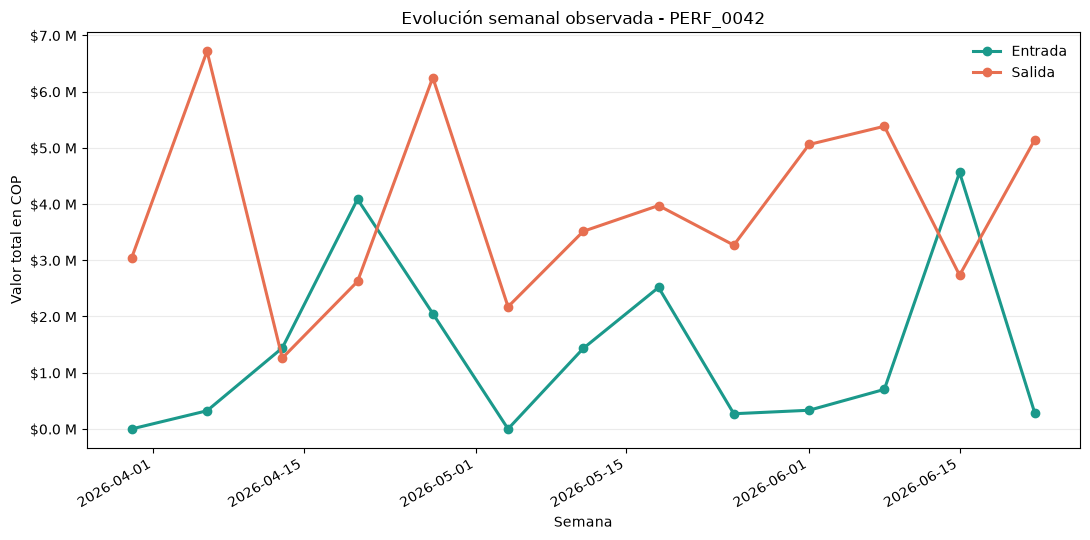

In [12]:
#Graficar evolución semanal
perfiles_regulares = recurrencias.loc[
    recurrencias['estado_patron'].eq('regularidad_observada'),
    'perfil_id',
].value_counts()
perfil_grafica = perfiles_regulares.index[0] if not perfiles_regulares.empty else transacciones['perfil_id'].iloc[0]

historia_grafica = transacciones.loc[transacciones['perfil_id'].eq(perfil_grafica)].copy()
historia_grafica['semana'] = historia_grafica['fecha'] - pd.to_timedelta(
    historia_grafica['fecha'].dt.weekday,
    unit='D',
)
serie_grafica = historia_grafica.pivot_table(
    index='semana',
    columns='direccion',
    values='valor',
    aggfunc='sum',
    fill_value=0,
).sort_index()

figura, eje = plt.subplots(figsize=(11, 5.5))
colores = {'entrada': '#1B998B', 'salida': '#E76F51'}

for direccion in ['entrada', 'salida']:
    if direccion in serie_grafica.columns:
        eje.plot(
            serie_grafica.index,
            serie_grafica[direccion],
            marker='o',
            linewidth=2.2,
            label=direccion.capitalize(),
            color=colores[direccion],
        )

eje.set_title(f'Evolución semanal observada - {perfil_grafica}')
eje.set_xlabel('Semana')
eje.set_ylabel('Valor total en COP')
eje.yaxis.set_major_formatter(FuncFormatter(lambda valor, posicion: f'${valor / 1_000_000:.1f} M'))
eje.legend(frameon=False)
eje.grid(axis='y', alpha=0.25)
figura.autofmt_xdate()
figura.tight_layout()

ruta_graficas.mkdir(parents=True, exist_ok=True)
figura.savefig(ruta_graficas / '03_evolucion_semanal_perfil.png', dpi=180, bbox_inches='tight')
plt.show()

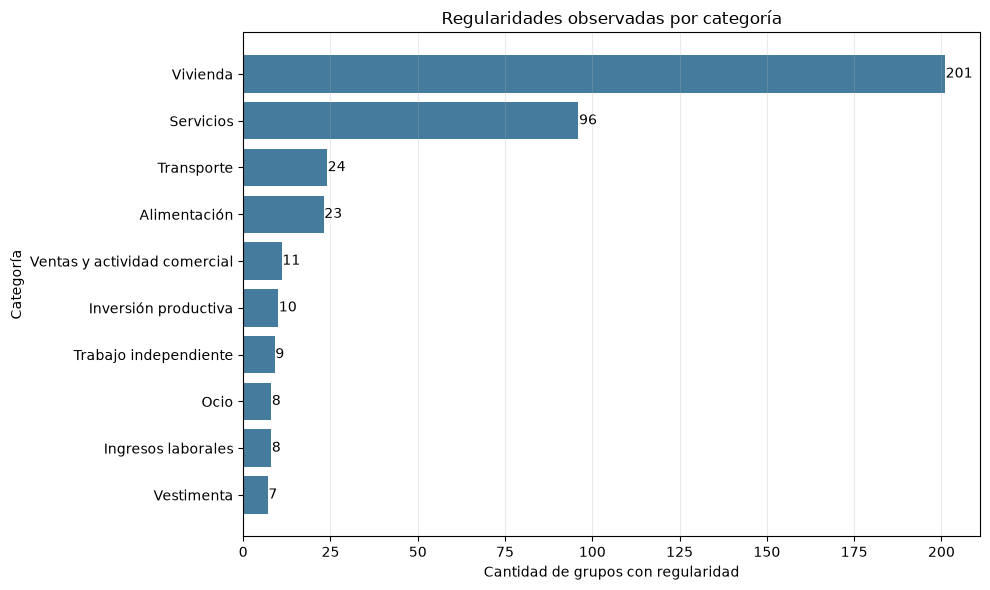

In [13]:
#Graficar regularidades
regularidades_categoria = recurrencias.loc[
    recurrencias['estado_patron'].eq('regularidad_observada')
].groupby('categoria_principal').size().sort_values(ascending=False).head(10).sort_values()

figura, eje = plt.subplots(figsize=(10, 6))
eje.barh(regularidades_categoria.index, regularidades_categoria.values, color='#457B9D')
eje.set_title('Regularidades observadas por categoría')
eje.set_xlabel('Cantidad de grupos con regularidad')
eje.set_ylabel('Categoría')
eje.grid(axis='x', alpha=0.25)

for posicion, valor in enumerate(regularidades_categoria.values):
    eje.text(valor + 0.2, posicion, str(int(valor)), va='center')

figura.tight_layout()
figura.savefig(ruta_graficas / '03_regularidades_por_categoria.png', dpi=180, bbox_inches='tight')
plt.show()

## 9. Exportación

In [ ]:
#Guardar resultados
ruta_resultados.mkdir(parents=True, exist_ok=True)

archivos_generados = {
    'recurrencias': ruta_resultados / '03_recurrencias_observadas.csv',
    'tendencias': ruta_resultados / '03_tendencias_observadas.csv',
    'eventos_inusuales': ruta_resultados / '03_eventos_inusuales.csv',
}

recurrencias.to_csv(archivos_generados['recurrencias'], index=False)
tendencias.to_csv(archivos_generados['tendencias'], index=False)
eventos_inusuales.to_csv(archivos_generados['eventos_inusuales'], index=False)

resumen_archivos = pd.DataFrame([
    {'resultado': nombre, 'ruta': str(ruta), 'filas': len(tabla)}
    for nombre, ruta, tabla in [
        ('recurrencias', archivos_generados['recurrencias'], recurrencias),
        ('tendencias', archivos_generados['tendencias'], tendencias),
        ('eventos_inusuales', archivos_generados['eventos_inusuales'], eventos_inusuales),
    ]
])

display(resumen_archivos)

## 10. Pruebas manuales

In [14]:
#Probar recurrencia mensual
test_recurrencia_mensual = pd.DataFrame([
    {'fecha': '2026-01-05', 'descripcion': 'pago arriendo', 'categoria': 'Vivienda', 'valor': 900000},
    {'fecha': '2026-02-05', 'descripcion': 'pago arriendo', 'categoria': 'Vivienda', 'valor': 900000},
    {'fecha': '2026-03-06', 'descripcion': 'pago arriendo', 'categoria': 'Vivienda', 'valor': 900000},
    {'fecha': '2026-04-05', 'descripcion': 'pago arriendo', 'categoria': 'Vivienda', 'valor': 900000},
])

resultado_recurrencia_mensual = pd.DataFrame([
    {
        'caso': 'recurrencia_mensual_clara',
        **evaluar_fechas(test_recurrencia_mensual['fecha']),
    }
])

display(test_recurrencia_mensual)
display(resultado_recurrencia_mensual)
assert resultado_recurrencia_mensual.loc[0, 'estado_patron'] == 'regularidad_observada'
assert resultado_recurrencia_mensual.loc[0, 'cadencia_observada'] == 'mensual'

,fecha,descripcion,categoria,valor
0,2026-01-05,pago arriendo,Vivienda,900000
1,2026-02-05,pago arriendo,Vivienda,900000
2,2026-03-06,pago arriendo,Vivienda,900000
3,2026-04-05,pago arriendo,Vivienda,900000


,caso,fechas_distintas,intervalo_mediano_dias,dispersion_intervalo_dias,cadencia_observada,regularidad_pct,estado_patron,nivel_incertidumbre
0,recurrencia_mensual_clara,4,30.0,1.0,mensual,100.0,regularidad_observada,baja


In [15]:
#Probar historia irregular
test_historia_irregular = pd.DataFrame([
    {'fecha': '2026-01-02', 'descripcion': 'compra variable', 'categoria': 'Otra / ambigua', 'valor': 35000},
    {'fecha': '2026-01-05', 'descripcion': 'compra variable', 'categoria': 'Otra / ambigua', 'valor': 42000},
    {'fecha': '2026-02-20', 'descripcion': 'compra variable', 'categoria': 'Otra / ambigua', 'valor': 28000},
    {'fecha': '2026-04-01', 'descripcion': 'compra variable', 'categoria': 'Otra / ambigua', 'valor': 51000},
])

resultado_historia_irregular = pd.DataFrame([
    {
        'caso': 'repeticion_sin_periodicidad',
        **evaluar_fechas(test_historia_irregular['fecha']),
    }
])

display(test_historia_irregular)
display(resultado_historia_irregular)
assert resultado_historia_irregular.loc[0, 'estado_patron'] == 'sin_regularidad_suficiente'
assert resultado_historia_irregular.loc[0, 'cadencia_observada'] == 'irregular'

,fecha,descripcion,categoria,valor
0,2026-01-02,compra variable,Otra / ambigua,35000
1,2026-01-05,compra variable,Otra / ambigua,42000
2,2026-02-20,compra variable,Otra / ambigua,28000
3,2026-04-01,compra variable,Otra / ambigua,51000


,caso,fechas_distintas,intervalo_mediano_dias,dispersion_intervalo_dias,cadencia_observada,regularidad_pct,estado_patron,nivel_incertidumbre
0,repeticion_sin_periodicidad,4,40.0,6.0,irregular,0.0,sin_regularidad_suficiente,media


In [16]:
#Probar historia insuficiente
test_historia_corta = pd.DataFrame([
    {'fecha': '2026-04-15', 'descripcion': 'compra única', 'categoria': 'Ocio', 'valor': 120000},
])

resultado_historia_corta = pd.DataFrame([
    {
        'caso': 'una_sola_transaccion',
        **evaluar_fechas(test_historia_corta['fecha']),
    }
])

display(test_historia_corta)
display(resultado_historia_corta)
assert resultado_historia_corta.loc[0, 'estado_patron'] == 'evidencia_insuficiente'
assert resultado_historia_corta.loc[0, 'cadencia_observada'] == 'no_determinable'

,fecha,descripcion,categoria,valor
0,2026-04-15,compra única,Ocio,120000


,caso,fechas_distintas,intervalo_mediano_dias,dispersion_intervalo_dias,cadencia_observada,regularidad_pct,estado_patron,nivel_incertidumbre
0,una_sola_transaccion,1,NaN,NaN,no_determinable,0.0,evidencia_insuficiente,alta
